In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('AAPL_data.csv')

In [3]:
data.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,12-12-1980,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,15-12-1980,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,16-12-1980,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,17-12-1980,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,18-12-1980,0.091530,0.118862,0.119420,0.118862,0.118862,73449600


In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11084 entries, 0 to 11083
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11084 non-null  object 
 1   Adj Close  11084 non-null  float64
 2   Close      11084 non-null  float64
 3   High       11084 non-null  float64
 4   Low        11084 non-null  float64
 5   Open       11084 non-null  float64
 6   Volume     11084 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 606.3+ KB
None


# Preprocessing the dataset for ARIMA model



In [5]:
data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
print(data['Date'])

0       1980-12-12
1       1980-12-15
2       1980-12-16
3       1980-12-17
4       1980-12-18
           ...    
11079   2024-11-22
11080   2024-11-25
11081   2024-11-26
11082   2024-11-27
11083   2024-11-29
Name: Date, Length: 11084, dtype: datetime64[ns]


In [6]:
data.sort_values('Date', inplace=True)

In [7]:
data.set_index('Date', inplace=True)

In [8]:
close_data = data['Close']

In [9]:
close_data.head()

Date
1980-12-12    0.128348
1980-12-15    0.121652
1980-12-16    0.112723
1980-12-17    0.115513
1980-12-18    0.118862
Name: Close, dtype: float64

In [10]:
close_data.describe()

count    11084.000000
mean        23.891777
std         49.215566
min          0.049107
25%          0.300223
50%          0.539733
75%         21.060982
max        237.330002
Name: Close, dtype: float64

In [11]:
close_data.isnull().sum()

0

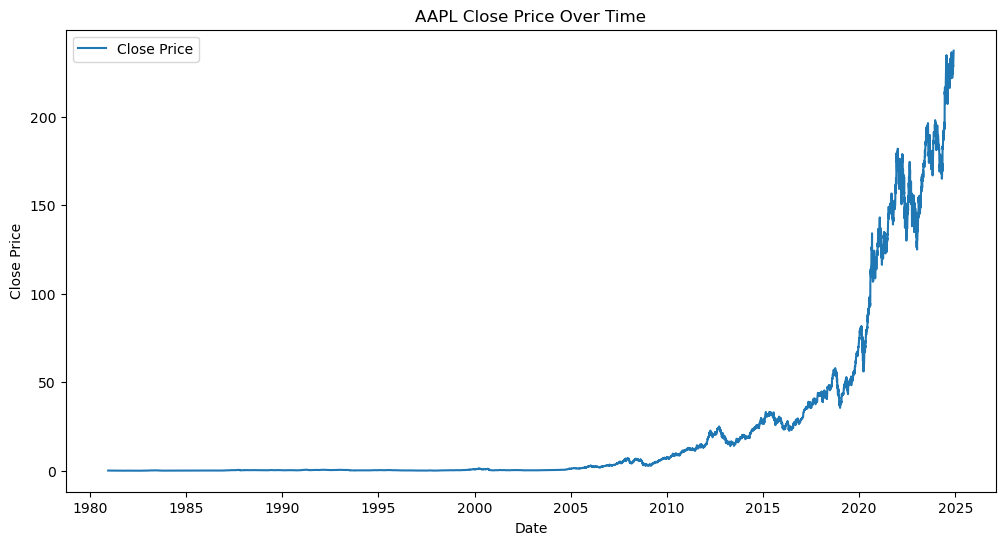

In [12]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Visualizing the 'Close' data over time
plt.figure(figsize=(12, 6))
plt.plot(close_data, label='Close Price')
plt.title('AAPL Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()



In [54]:
#ADF tset
adf_test = adfuller(close_data)
adf_results = {
    "ADF Statistic": adf_test[0],
    "p-value": adf_test[1],
    "Critical Values": adf_test[4],
}

In [55]:
adf_results

{'ADF Statistic': 4.166305195698865,
 'p-value': 1.0,
 'Critical Values': {'1%': -3.4309222457742283,
  '5%': -2.8617929020765684,
  '10%': -2.5669046146768837}}

#### This suggests that the data is not stationary, and differencing is required to make it suitable for ARIMA modeling. 
#### we need to perform differencing until the data becomes stationary

In [15]:
# Perform differencing to make the data stationary
diff_close_data = close_data.diff().dropna()

In [56]:
# ADF test
adf_test_diff = adfuller(diff_close_data)
adf_diff_results = {
    "ADF Statistic": adf_test_diff[0],
    "p-value": adf_test_diff[1],
    "Critical Values": adf_test_diff[4],
}

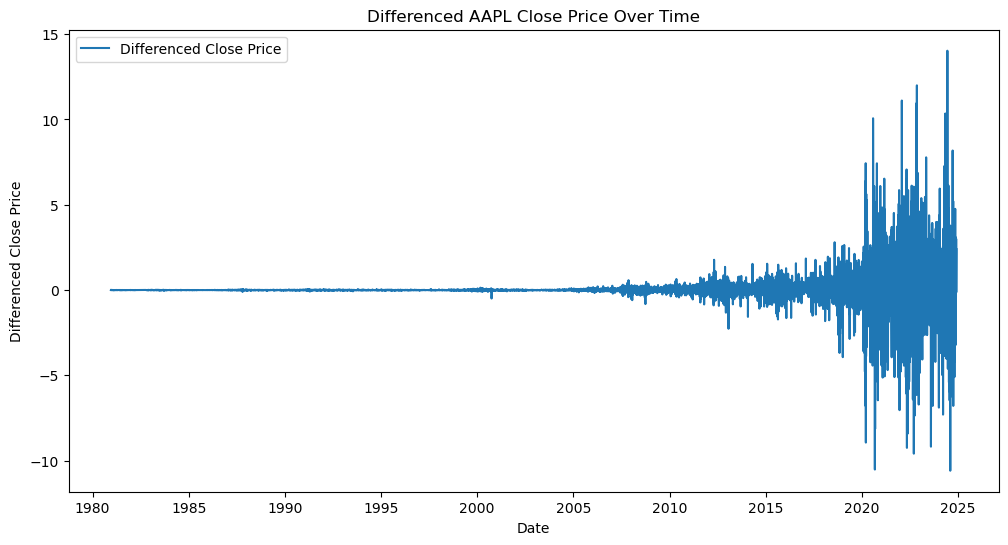

In [57]:
# Visualize the differenced data
plt.figure(figsize=(12, 6))
plt.plot(diff_close_data, label='Differenced Close Price')
plt.title('Differenced AAPL Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.legend()
plt.show()

In [58]:
adf_diff_results

{'ADF Statistic': -17.712467432806577,
 'p-value': 3.497302036118693e-30,
 'Critical Values': {'1%': -3.4309423046915986,
  '5%': -2.8618017661630577,
  '10%': -2.5669093330045536}}

In [59]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

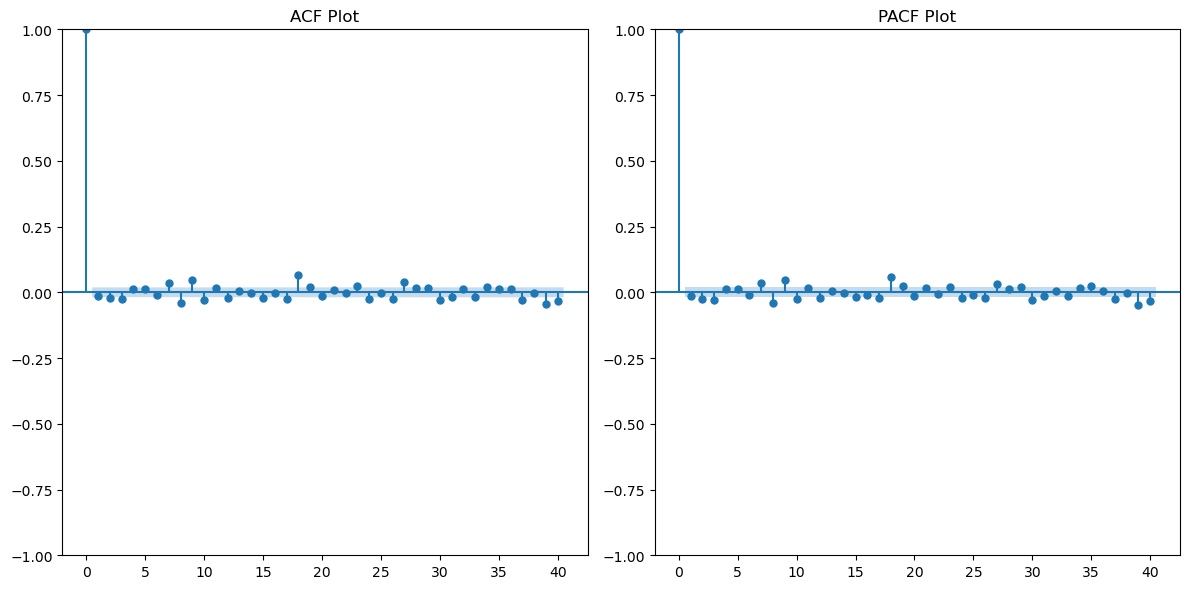

In [60]:
# ACF and PACF Plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_acf(diff_close_data, ax=plt.gca(), lags=40)
plt.title('ACF Plot')

plt.subplot(1, 2, 2)
plot_pacf(diff_close_data, ax=plt.gca(), lags=40, method='ywm')
plt.title('PACF Plot')

plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                11471
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -15217.690
Date:                Tue, 14 Jul 2026   AIC                          30445.380
Time:                        20:49:18   BIC                          30482.117
Sample:                    12-12-1980   HQIC                         30457.731
                         - 11-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5108      0.000   1653.289      0.000       0.510       0.511
ar.L2         -0.9984      0.000  -3483.037      0.000      -0.999      -0.998
ma.L1         -0.5165      0.000  -1645.069      0.0

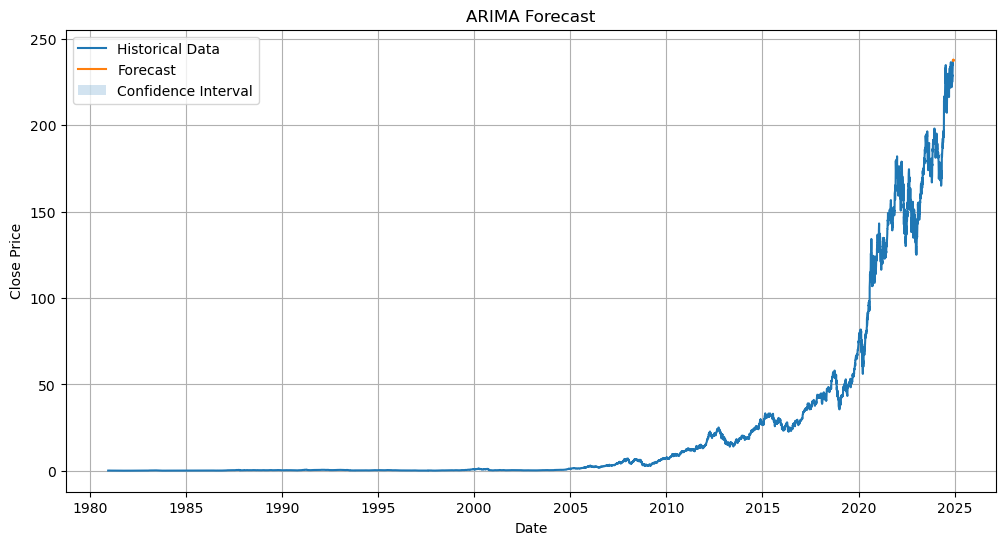


Performance Metrics
-------------------
MSE : 0.8314120612073729
RMSE: 0.9118179978522978
MAE : 0.29615102446008107
MAPE: 0.018730349474328303
R²  : 0.9996573486440414


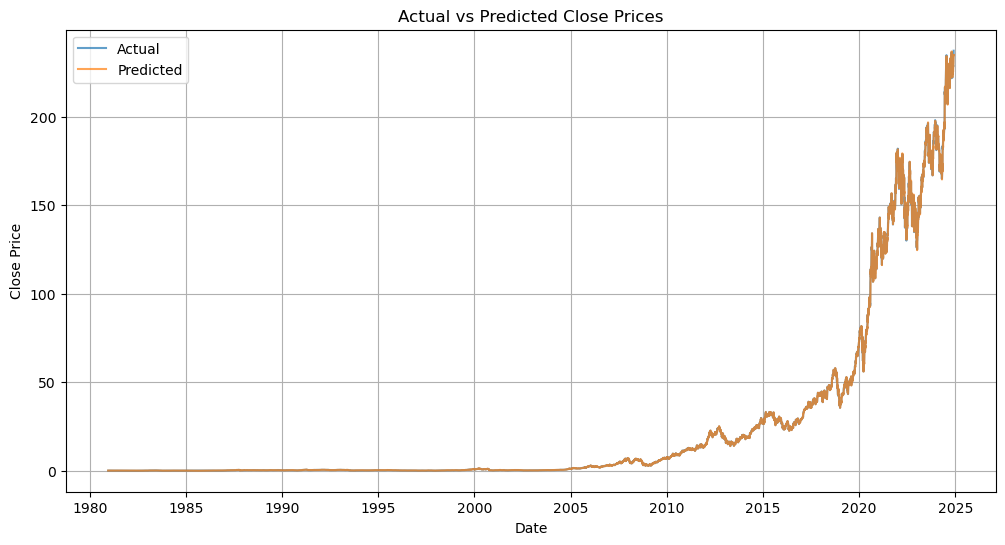

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

# =========================
# Prepare Data
# =========================

close_data.index = pd.to_datetime(close_data.index)

freq = pd.infer_freq(close_data.index)

if freq is not None:
    close_data = close_data.asfreq(freq)
else:
    # Business-day frequency for stock market data
    close_data = close_data.asfreq('B')

close_data = close_data.ffill()

# =========================
# Fit ARIMA Model
# =========================

p = 2
d = 1
q = 2

arima_model = ARIMA(close_data, order=(p, d, q))
arima_result = arima_model.fit()

print(arima_result.summary())

# =========================
# Forecast Future Values
# =========================

forecast_steps = 10

forecast_result = arima_result.get_forecast(steps=forecast_steps)

forecast_values = forecast_result.predicted_mean
forecast_conf_int = forecast_result.conf_int()

# Create future dates
last_date = close_data.index[-1]

forecast_dates = pd.date_range(
    start=last_date + pd.offsets.BDay(1),
    periods=forecast_steps,
    freq='B'
)

forecast_values.index = forecast_dates
forecast_conf_int.index = forecast_dates

print("\nForecast Values:")
print(forecast_values)

# =========================
# Plot Historical + Forecast
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    close_data.index,
    close_data.values,
    label='Historical Data'
)

plt.plot(
    forecast_dates,
    forecast_values,
    label='Forecast'
)

plt.fill_between(
    forecast_dates,
    forecast_conf_int.iloc[:, 0],
    forecast_conf_int.iloc[:, 1],
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.show()

# =========================
# Model Evaluation
# =========================

predictions = arima_result.fittedvalues

actual_values = close_data.iloc[d:]
predictions = predictions.iloc[d:]

# Align indices
actual_values, predictions = actual_values.align(
    predictions,
    join='inner'
)

mse = mean_squared_error(actual_values, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_values, predictions)
mape = mean_absolute_percentage_error(actual_values, predictions)
r2 = r2_score(actual_values, predictions)

print("\nPerformance Metrics")
print("-------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R²  :", r2)

# =========================
# Actual vs Predicted Plot
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    actual_values.index,
    actual_values,
    label='Actual',
    alpha=0.7
)

plt.plot(
    predictions.index,
    predictions,
    label='Predicted',
    alpha=0.7
)

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)

plt.show()

In [62]:
# Ensure forecast values and confidence intervals are properly converted to numeric
forecast_values = forecast_values.astype(float)
forecast_conf_int = forecast_conf_int.astype(float)

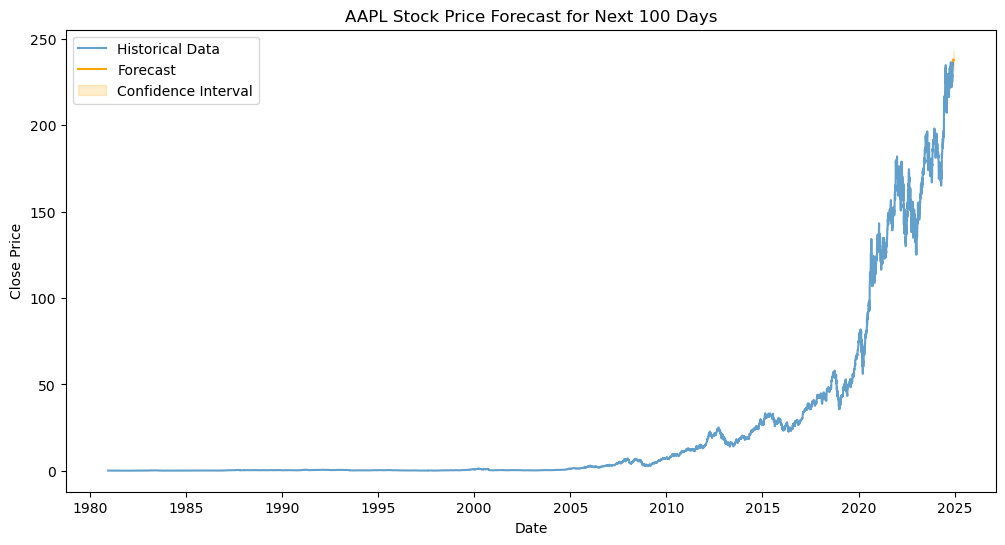

In [69]:
# Re-plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(close_data, label='Historical Data', alpha=0.7)
plt.plot(forecast_dates, forecast_values, label='Forecast', color='orange')
plt.fill_between(
    forecast_dates,
    forecast_conf_int.iloc[:, 0],
    forecast_conf_int.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Confidence Interval',
)
plt.title('AAPL Stock Price Forecast for Next 100 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [70]:
# Inspect data types of forecasted values and confidence intervals
forecast_values_dtype = forecast_values.dtype
forecast_conf_int_dtypes = forecast_conf_int.dtypes

forecast_values_dtype, forecast_conf_int_dtypes

(dtype('float64'),
 lower Close    float64
 upper Close    float64
 dtype: object)

In [71]:
# Reset indices of forecast confidence intervals and forecast values
forecast_conf_int.reset_index(drop=True, inplace=True)
forecast_conf_int.index = forecast_dates

forecast_values = pd.Series(forecast_values.values, index=forecast_dates)

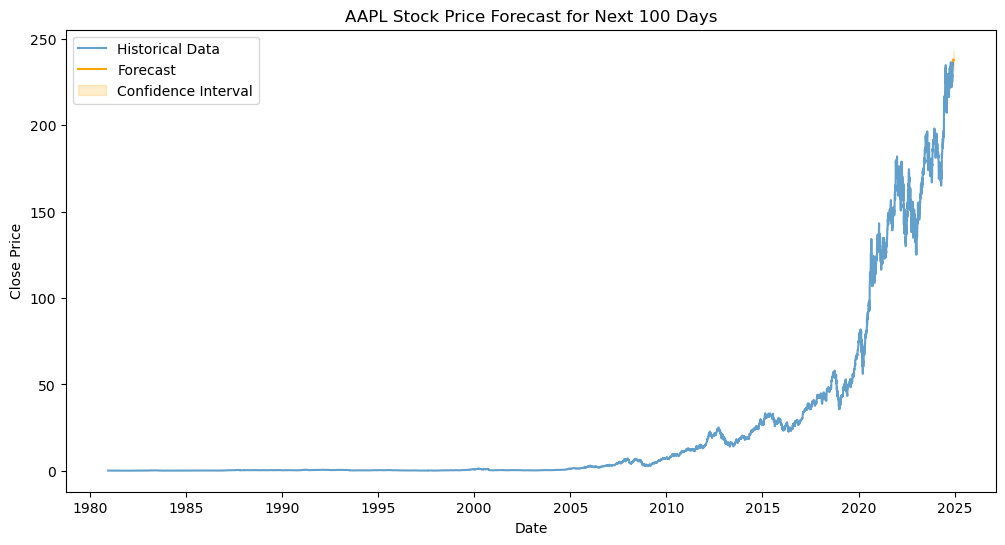

In [72]:
# Re-plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(close_data, label='Historical Data', alpha=0.7)
plt.plot(forecast_dates, forecast_values, label='Forecast', color='orange')
plt.fill_between(
    forecast_dates,
    forecast_conf_int.iloc[:, 0],
    forecast_conf_int.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Confidence Interval',
)
plt.title('AAPL Stock Price Forecast for Next 100 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [74]:
# Inspect indices and lengths for consistency
forecast_values_index = forecast_values.index
forecast_conf_int_index = forecast_conf_int.index
forecast_dates_length = len(forecast_dates)
forecast_values_length = len(forecast_values)
forecast_conf_int_length = len(forecast_conf_int)

forecast_values_index, forecast_conf_int_index, forecast_dates_length, forecast_values_length, forecast_conf_int_length

(DatetimeIndex(['2024-12-02', '2024-12-03', '2024-12-04', '2024-12-05',
                '2024-12-06', '2024-12-09', '2024-12-10', '2024-12-11',
                '2024-12-12', '2024-12-13'],
               dtype='datetime64[ns]', freq='B'),
 DatetimeIndex(['2024-12-02', '2024-12-03', '2024-12-04', '2024-12-05',
                '2024-12-06', '2024-12-09', '2024-12-10', '2024-12-11',
                '2024-12-12', '2024-12-13'],
               dtype='datetime64[ns]', freq='B'),
 10,
 10,
 10)

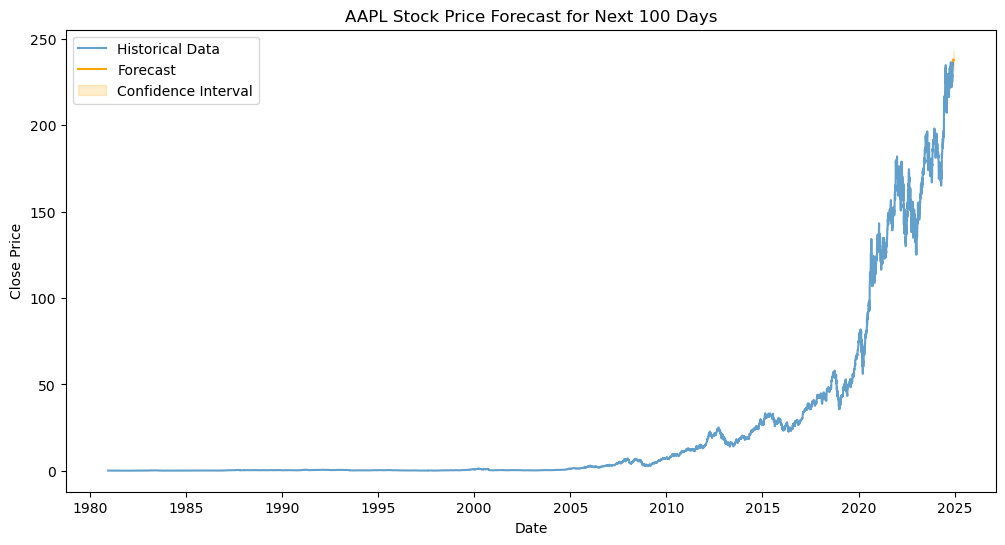

In [75]:
# Reattempt plotting with explicit validation
plt.figure(figsize=(12, 6))
plt.plot(close_data, label='Historical Data', alpha=0.7)
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='orange')
plt.fill_between(
    forecast_values.index,
    forecast_conf_int.iloc[:, 0],
    forecast_conf_int.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='Confidence Interval',
)
plt.title('AAPL Stock Price Forecast for Next 100 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [76]:
forecast_conf_int = forecast_conf_int.apply(pd.to_numeric, errors='coerce')

In [77]:
invalid_conf_int_check = forecast_conf_int.isnull().sum()

invalid_forecast_values_check = forecast_values.isnull().sum()

invalid_conf_int_check, invalid_forecast_values_check

(lower Close    0
 upper Close    0
 dtype: int64,
 0)

In [78]:
# Inspect the content and data types of forecast_conf_int and forecast_values
forecast_conf_int_info = forecast_conf_int.dtypes
forecast_values_info = forecast_values.dtypes

# Display the first few rows of forecast_conf_int and forecast_values for validation
forecast_conf_int_preview = forecast_conf_int.head()
forecast_values_preview = forecast_values.head()

forecast_conf_int_info, forecast_conf_int_preview, forecast_values_info, forecast_values_preview

(lower Close    float64
 upper Close    float64
 dtype: object,
             lower Close  upper Close
 2024-12-02   235.979027   239.553388
 2024-12-03   235.432768   240.473257
 2024-12-04   234.532882   240.692933
 2024-12-05   233.696530   240.808791
 2024-12-06   233.428148   241.388289,
 dtype('float64'),
 2024-12-02    237.766207
 2024-12-03    237.953013
 2024-12-04    237.612907
 2024-12-05    237.252661
 2024-12-06    237.408219
 Freq: B, dtype: float64)

In [79]:
# Convert all data to numpy arrays for compatibility with matplotlib
forecast_values_array = forecast_values.values
lower_conf_array = forecast_conf_int.iloc[:, 0].values
upper_conf_array = forecast_conf_int.iloc[:, 1].values
forecast_dates_array = forecast_values.index

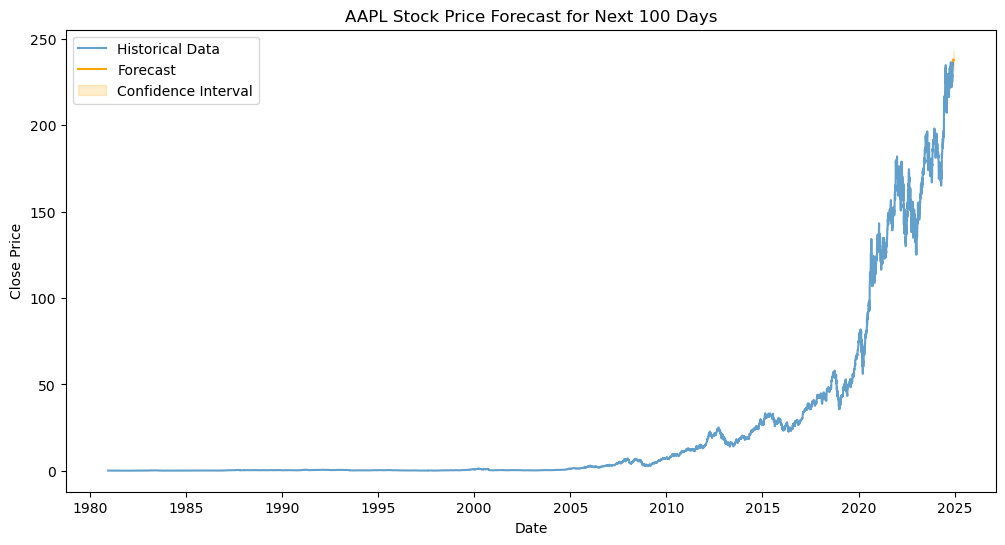

In [80]:
# Plot the forecast with numpy arrays
plt.figure(figsize=(12, 6))
plt.plot(close_data, label='Historical Data', alpha=0.7)
plt.plot(forecast_dates_array, forecast_values_array, label='Forecast', color='orange')
plt.fill_between(
    forecast_dates_array,
    lower_conf_array,
    upper_conf_array,
    color='orange',
    alpha=0.2,
    label='Confidence Interval',
)
plt.title('AAPL Stock Price Forecast for Next 100 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()